In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt


from pathlib import Path

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [3]:
# Download NLTK Resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sweta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sweta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sweta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sweta\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sweta\AppData\Roaming\nltk_data...


KeyboardInterrupt: 

In [5]:
# Load Dataset
# Define project paths

BASE_DIR = Path("..")
DATA_PATH = BASE_DIR / "data" / "feedback.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (60889, 6)


,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating
0,136040,smartTv,Nice one,I liked it,5,Positive
1,134236,mobile,Huge battery life with amazing display,I bought the phone on Amazon and been using my...,5,Positive
2,113945,books,Four Stars,"Awesome book at reasonable price, must buy ......",4,Positive
3,168076,smartTv,Nice quality,good,5,Positive
4,157302,books,Nice book,"The book is fine,not bad,contains nice concept...",3,Neutral


In [7]:
# Find the Review Column
required_columns = [
    "Unique_ID",
    "Category",
    "Review_Header",
    "Review_text",
    "Rating",
    "Own_Rating"
]

print("Required columns:")
print(required_columns)

print("\nMissing columns:")

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print(missing_columns)

Required columns:
['Unique_ID', 'Category', 'Review_Header', 'Review_text', 'Rating', 'Own_Rating']

Missing columns:
[]


In [39]:
# This tells us whether we need to handle missing/empty textual data before NLP processing.
print("Missing Review_Header:",
      df["Review_Header"].isna().sum())

print("Missing Review_text:",
      df["Review_text"].isna().sum())
print(
    "Empty Review_Header:",
    (df["Review_Header"].fillna("").str.strip() == "").sum()
)

print(
    "Empty Review_text:",
    (df["Review_text"].fillna("").str.strip() == "").sum())
# Check rows where both text fields are missing/empty

both_missing = (
    df["Review_Header"].fillna("").str.strip().eq("")
    &
    df["Review_text"].fillna("").str.strip().eq("")
)

print(
    "Rows where both Review_Header and Review_text are missing:",
    both_missing.sum()
)

df.loc[
    both_missing,
    [
        "Unique_ID",
        "Category",
        "Review_Header",
        "Review_text",
        "Rating",
        "Own_Rating"
    ]
]
nlp_df = df[~both_missing].copy()
print("Original dataset shape:", df.shape)
print("NLP dataset shape:", nlp_df.shape)
nlp_df["Review_Header"] = nlp_df["Review_Header"].fillna("")
nlp_df["Review_text"] = nlp_df["Review_text"].fillna("")
nlp_df["Combined_Text"] = (
    nlp_df["Review_Header"] + " " + nlp_df["Review_text"]
).str.strip()
print("Empty Combined_Text:", 
      (nlp_df["Combined_Text"].str.strip() == "").sum())


Missing Review_Header: 5
Missing Review_text: 32
Empty Review_Header: 5
Empty Review_text: 32
Rows where both Review_Header and Review_text are missing: 3
Original dataset shape: (60889, 10)
NLP dataset shape: (60886, 10)
Empty Combined_Text: 0


In [42]:
# Combine Review Header + Review Text
nlp_df["Combined_Text"] = (
    nlp_df["Review_Header"].fillna("").astype(str)
    + " "
    + nlp_df["Review_text"].fillna("").astype(str)
).str.strip()
nlp_df[
    ["Review_Header", "Review_text", "Combined_Text"]
].head(5)

,Review_Header,Review_text,Combined_Text
0,Nice one,I liked it,Nice one I liked it
1,Huge battery life with amazing display,I bought the phone on Amazon and been using my...,Huge battery life with amazing display I bough...
2,Four Stars,"Awesome book at reasonable price, must buy ......","Four Stars Awesome book at reasonable price, m..."
3,Nice quality,good,Nice quality good
4,Nice book,"The book is fine,not bad,contains nice concept...","Nice book The book is fine,not bad,contains ni..."


In [43]:
# Initialize NLP tools

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

print("Number of English stopwords:", len(stop_words))

Number of English stopwords: 198


In [44]:
# Important: Preserve Negation Words

# For sentiment analysis, we should not blindly remove every NLTK stopword.
# Preserve important negation words

negation_words = {
    "no",
    "not",
    "never",
    "nor",
    "neither",
    "hardly",
    "scarcely",
    "barely"
}

custom_stop_words = stop_words - negation_words

print("Original stopwords:", len(stop_words))
print("Custom stopwords:", len(custom_stop_words))

Original stopwords: 198
Custom stopwords: 195


In [45]:
# Create Text Cleaning Function
def preprocess_text(text):
    
    # Handle missing values
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )
    
    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        "",
        text
    )
    
    # Normalize repeated characters
    text = re.sub(
        r"(.)\1{2,}",
        r"\1\1",
        text
    )
    
    # Remove numbers
    text = re.sub(
        r"\d+",
        "",
        text
    )
    
    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    
    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [
        word
        for word in tokens
        if word not in custom_stop_words
    ]
    
    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    
    # Convert tokens back to text
    cleaned_text = " ".join(tokens)
    
    return cleaned_text

In [46]:
# Test the Function Before Applying to Dataset
sample_text = """
This phone is NOT good!!! 
The battery is soooo bad.
Visit https://example.com
"""

print("Original:")
print(sample_text)

print("\nProcessed:")
print(preprocess_text(sample_text))

Original:

This phone is NOT good!!! 
The battery is soooo bad.
Visit https://example.com


Processed:
phone not good battery soo bad visit


In [17]:
# Apply Preprocessing to Dataset
nlp_df["Cleaned_Text"] = nlp_df["Combined_Text"].apply(
    preprocess_text
)
nlp_df[
    [
        "Review_Header",
        "Review_text",
        "Combined_Text",
        "Cleaned_Text",
        "Own_Rating"
    ]
].head(10)

,Review_Header,Review_text,Combined_Text,Cleaned_Text,Own_Rating
0,Nice one,I liked it,Nice one I liked it,nice one liked,Positive
1,Huge battery life with amazing display,I bought the phone on Amazon and been using my...,Huge battery life with amazing display I bough...,huge battery life amazing display bought phone...,Positive
2,Four Stars,"Awesome book at reasonable price, must buy ......","Four Stars Awesome book at reasonable price, m...",four star awesome book reasonable price must buy,Positive
3,Nice quality,good,Nice quality good,nice quality good,Positive
4,Nice book,"The book is fine,not bad,contains nice concept...","Nice book The book is fine,not bad,contains ni...",nice book book finenot badcontains nice concep...,Neutral
5,Nice tv,Nice tv and pic quality .good custmer srrvice ...,Nice tv Nice tv and pic quality .good custmer ...,nice tv nice tv pic quality good custmer srrvi...,Positive
6,Beauty and the Beast,The iPhone 7 is legitimately among the most in...,Beauty and the Beast The iPhone 7 is legitimat...,beauty beast iphone legitimately among interes...,Positive
7,"20000 mAH, what more you need","20000 mAH, what more you need. Super product","20000 mAH, what more you need 20000 mAH, what ...",mah need mah need super product,Positive
8,Need more good quality,The company should give more Bettany backup an...,Need more good quality The company should give...,need good quality company give bettany backup ...,Negative
9,Good phone,Very good phone,Good phone Very good phone,good phone good phone,Positive


In [47]:
#Compare Before and After
comparison = nlp_df[
    [
        "Combined_Text",
        "Cleaned_Text",
        "Own_Rating"
    ]
].head(10)

comparison

,Combined_Text,Cleaned_Text,Own_Rating
0,Nice one I liked it,nice one liked,Positive
1,Huge battery life with amazing display I bough...,huge battery life amazing display bought phone...,Positive
2,"Four Stars Awesome book at reasonable price, m...",four star awesome book reasonable price must buy,Positive
3,Nice quality good,nice quality good,Positive
4,"Nice book The book is fine,not bad,contains ni...",nice book book finenot badcontains nice concep...,Neutral
5,Nice tv Nice tv and pic quality .good custmer ...,nice tv nice tv pic quality good custmer srrvi...,Positive
6,Beauty and the Beast The iPhone 7 is legitimat...,beauty beast iphone legitimately among interes...,Positive
7,"20000 mAH, what more you need 20000 mAH, what ...",mah need mah need super product,Positive
8,Need more good quality The company should give...,need good quality company give bettany backup ...,Negative
9,Good phone Very good phone,good phone good phone,Positive


In [49]:
# Calculate Text Statistics
nlp_df["Original_Word_Count"] = (
    df["Combined_Text"]
    .fillna("")
    .str.split()
    .str.len()
)

In [48]:
nlp_df["Cleaned_Word_Count"] = (
    nlp_df["Cleaned_Text"]
    .fillna("")
    .str.split()
    .str.len()
)

In [50]:
nlp_df[
    [
        "Original_Word_Count",
        "Cleaned_Word_Count"
    ]
].describe()

,Original_Word_Count,Cleaned_Word_Count
count,60886.000000,60886.000000
mean,29.072118,17.571182
std,57.044658,31.662445
min,1.000000,0.000000
25%,6.000000,4.000000
50%,14.000000,9.000000
75%,33.000000,20.000000
max,3325.000000,1815.000000


In [51]:
# Average word count
print(
    "Average original word count:",
    round(nlp_df["Original_Word_Count"].mean(), 2)
)

print(
    "Average cleaned word count:",
    round(nlp_df["Cleaned_Word_Count"].mean(), 2))

# The preprocessing pipeline reduced the average number 
# of words by removing punctuation, URLs, stopwords, and unnecessary 
# tokens while preserving important sentiment-related words.

Average original word count: 29.07
Average cleaned word count: 17.57


In [52]:
# Check Empty Text After Preprocessing
empty_cleaned = (
    nlp_df["Cleaned_Text"]
    .fillna("")
    .str.strip()
    .eq("")
)

print(
    "Empty texts after preprocessing:",
    empty_cleaned.sum()
)
nlp_df.loc[
    empty_cleaned,
    [
        "Unique_ID",
        "Review_Header",
        "Review_text",
        "Own_Rating"
    ]
].head(20)

Empty texts after preprocessing: 13


,Unique_ID,Review_Header,Review_text,Own_Rating
2179,110991,A1,A1,Positive
2759,154623,.,So so,Positive
3130,166959,You,You,Positive
20764,110992,A1,A1,Positive
23328,110477,A,A,Positive
28026,110078,-,-,Positive
29643,110241,101,10,Positive
31549,114983,Awwwwwwwewwweeeeeeeesome,Awwwwwwwewwweeeeeeeesome,Positive
39108,110440,679794,679794,Positive
41132,110453,85000!!!,85000!!!,Negative


In [27]:
# Analyze Text Length by Sentiment
sentiment_text_stats = (
    nlp_df.groupby("Own_Rating")["Cleaned_Word_Count"]
    .agg(
        ["count", "mean", "min", "max"]
    )
    .round(2)
)



sentiment_text_stats

# Whether positive, neutral, and negative reviews tend to differ in average length.

,count,mean,min,max
Own_Rating,,,,
Negative,9087,21.69,0,485
Neutral,4366,20.44,1,552
Positive,47436,16.52,0,1815


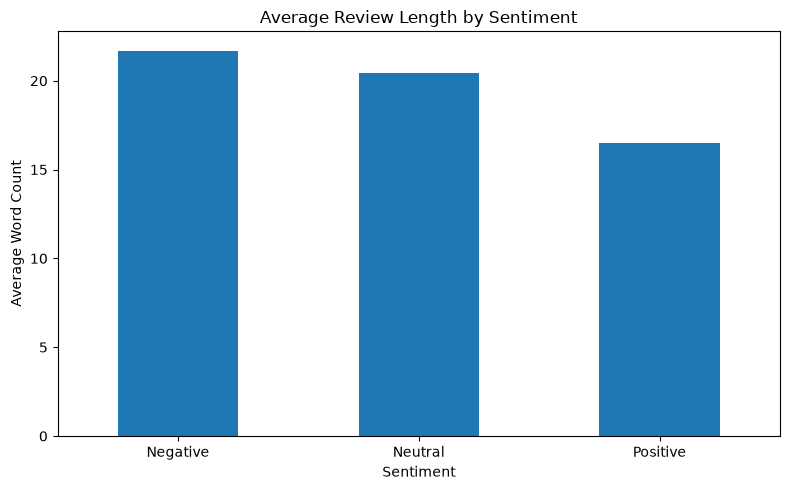

In [53]:
# Visualize Average Review Length
average_length = (
    nlp_df.groupby("Own_Rating")["Cleaned_Word_Count"]
    .mean()
)

plt.figure(figsize=(8, 5))

average_length.plot(kind="bar")

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [54]:
# Most Frequent Words
from collections import Counter
all_words = []

for text in nlp_df["Cleaned_Text"]:
    all_words.extend(text.split())

word_frequency = Counter(all_words)

word_frequency.most_common(20)

[('good', 42058),
 ('phone', 28008),
 ('not', 20707),
 ('product', 19907),
 ('camera', 14733),
 ('quality', 14572),
 ('battery', 14388),
 ('best', 11098),
 ('nice', 10279),
 ('price', 9692),
 ('one', 8353),
 ('great', 7776),
 ('mobile', 7198),
 ('awesome', 6751),
 ('no', 6551),
 ('buy', 6547),
 ('money', 6017),
 ('day', 5898),
 ('like', 5896),
 ('life', 5818)]

In [55]:
# Most Frequent Words by Sentiment
positive_words = []

for text in nlp_df.loc[
    df["Own_Rating"] == "Positive",
    "Cleaned_Text"
]:
    positive_words.extend(text.split())

positive_frequency = Counter(positive_words)

positive_frequency.most_common(20)

[('good', 36175),
 ('phone', 21074),
 ('product', 14864),
 ('camera', 11376),
 ('battery', 11154),
 ('quality', 10932),
 ('best', 10659),
 ('nice', 9738),
 ('not', 9227),
 ('price', 8565),
 ('great', 7279),
 ('awesome', 6559),
 ('one', 6198),
 ('mobile', 5013),
 ('life', 4848),
 ('money', 4726),
 ('excellent', 4448),
 ('no', 4418),
 ('like', 4389),
 ('sound', 4273)]

In [57]:
negative_words = []

for text in nlp_df.loc[
    nlp_df["Own_Rating"] == "Negative",
    "Cleaned_Text"
]:
    negative_words.extend(text.split())

negative_frequency = Counter(negative_words)

negative_frequency.most_common(20)

[('not', 8084),
 ('phone', 4814),
 ('product', 4033),
 ('good', 2525),
 ('quality', 2333),
 ('buy', 2155),
 ('working', 1988),
 ('dont', 1977),
 ('worst', 1903),
 ('bad', 1897),
 ('camera', 1883),
 ('amazon', 1882),
 ('battery', 1805),
 ('mobile', 1630),
 ('one', 1607),
 ('no', 1571),
 ('day', 1378),
 ('poor', 1347),
 ('time', 1299),
 ('month', 1263)]

In [59]:
# Neutral
neutral_words = []

for text in nlp_df.loc[
    nlp_df["Own_Rating"] == "Neutral",
    "Cleaned_Text"
]:
    neutral_words.extend(text.split())

neutral_frequency = Counter(neutral_words)

neutral_frequency.most_common(20)

[('not', 3396),
 ('good', 3358),
 ('phone', 2120),
 ('camera', 1474),
 ('battery', 1429),
 ('quality', 1307),
 ('product', 1010),
 ('ok', 620),
 ('average', 605),
 ('price', 596),
 ('no', 562),
 ('like', 555),
 ('mobile', 555),
 ('sound', 548),
 ('one', 548),
 ('time', 526),
 ('life', 476),
 ('day', 476),
 ('better', 467),
 ('issue', 465)]

In [58]:
# Save the Preprocessed Dataset
OUTPUT_PATH = BASE_DIR / "data" / "feedback_preprocessed.csv"

output_columns = [
    "Unique_ID",
    "Category",
    "Review_Header",
    "Review_text",
    "Rating",
    "Own_Rating",
    "Combined_Text",
    "Cleaned_Text"
]

nlp_df[output_columns].to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved to:", OUTPUT_PATH)

Saved to: ..\data\feedback_preprocessed.csv


In [60]:
# Final Verification
processed_df = pd.read_csv(OUTPUT_PATH)

print("Processed dataset shape:", processed_df.shape)

print("\nColumns:")
print(processed_df.columns.tolist())

print("\nFirst 5 rows:")
display(processed_df.head())

Processed dataset shape: (60886, 8)

Columns:
['Unique_ID', 'Category', 'Review_Header', 'Review_text', 'Rating', 'Own_Rating', 'Combined_Text', 'Cleaned_Text']

First 5 rows:


,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating,Combined_Text,Cleaned_Text
0,136040,smartTv,Nice one,I liked it,5,Positive,Nice one I liked it,nice one liked
1,134236,mobile,Huge battery life with amazing display,I bought the phone on Amazon and been using my...,5,Positive,Huge battery life with amazing display I bough...,huge battery life amazing display bought phone...
2,113945,books,Four Stars,"Awesome book at reasonable price, must buy ......",4,Positive,"Four Stars Awesome book at reasonable price, m...",four star awesome book reasonable price must buy
3,168076,smartTv,Nice quality,good,5,Positive,Nice quality good,nice quality good
4,157302,books,Nice book,"The book is fine,not bad,contains nice concept...",3,Neutral,"Nice book The book is fine,not bad,contains ni...",nice book book finenot badcontains nice concep...
